Import Libraries

In [35]:
import pandas as pd                            # DataFrame operations
import numpy as np                             # Numerical computing
import matplotlib.pyplot as plt                # Visualization
import seaborn as sns                          # Statistical plots
from sklearn.svm import SVC                    # Support Vector Classifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import time
import os

Load The Preprocessed Datas Training\Test

In [36]:
df_train=pd.read_csv("Final_train_data.csv")
df_test=pd.read_csv("Final_test_data.csv")

FIRST : Model Using The Same Datas For Training and Test

In [37]:
x_train = df_train.drop(columns=["Class"]) #features (data without Class)
y_train = df_train["Class"] #labels (Class)

Define SVM Kernels

In [38]:
kernel_params = {
    "linear" : {
        "C" : [0.1, 1, 10, 100, 1000, 10000]
    },
    "rbf" : {
        "C" : [0.1, 1, 10, 100, 1000],
        "gamma" : [0.001, 0.01, 0.1, 1, 10]
    },
    "poly" : {
        "C" : [0.1, 1, 10, 100],
        "degree" : [2, 3, 4, 5],
        "gamma" : ['scale', 'auto']
    },
    "sigmoid" : {
        "C" : [0.1, 1, 10, 100],
        "gamma" : ['scale', 'auto']
    }
}

In [44]:
def train_and_evaluate_svm_with_portion(portion, kernel_params):
    
    os.makedirs("confusion_matrices_diff_datas", exist_ok=True)

    # Step 1: Subset the training data using stratified split
    
    if portion < 1.0:
        x_train_subset, _, y_train_subset, _ = train_test_split(
            x_train, y_train,
            train_size=portion,
            stratify=y_train,
            random_state=42
        )
    else:
        x_train_subset = x_train.copy()
        y_train_subset = y_train.copy()
        
    print(f"\n Training with {portion*100:.1f}% of the data ({len(x_train_subset)} samples)")
    
    # Step 2: Print class distribution in this subset
    dist = y_train_subset.value_counts()
    print("\n Class distribution in training subset:")
    for label, count in dist.items():
        print(f" - Class {label}: {count} samples")

    best_models = {}  # To store best models for each kernel

    # Step 3: Train and evaluate for each kernel independently
    for kernel_name, param_grid in kernel_params.items():
        print(f"\n Training SVM with kernel: {kernel_name.upper()}")

        model = SVC(kernel=kernel_name)

        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            scoring="accuracy",
            cv=5,
            verbose=1,
            n_jobs=-1
        )

        start = time.time()
        grid.fit(x_train_subset, y_train_subset)
        end = time.time()
        elapsed = end - start

        best_model = grid.best_estimator_
        best_models[kernel_name] = best_model

        # Evaluation on test set
        y_pred = best_model.predict(x_test)

        print(f"\n Best parameters for {kernel_name}: {grid.best_params_}")
        print("\n Classification Report:")
        print(classification_report(y_test, y_pred))
        acc = accuracy_score(y_test, y_pred)
        print(f" Accuracy: {acc:.6f}")
        print(f"️ Training Time: {elapsed:.4f} seconds")

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
        plt.title(f"Confusion Matrix - {kernel_name.upper()} Kernel ({portion*100:.0f}%)")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()

        # Save confusion matrix with portion and kernel
        filename = f"confusion_matrices_diff_datas/confusion_matrix_{kernel_name}_{int(portion * 100)}.png"
        plt.savefig(filename, dpi=300)
        plt.show()
        #print(f"️ Confusion matrix saved as: {filename}")

    return best_models



 Training with 10.0% of the data (300 samples)

 Class distribution in training subset:
 - Class 0: 166 samples
 - Class 1: 134 samples

 Training SVM with kernel: LINEAR
Fitting 5 folds for each of 6 candidates, totalling 30 fits

 Best parameters for linear: {'C': 10}

 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1663
           1       0.98      0.97      0.98      1346

    accuracy                           0.98      3009
   macro avg       0.98      0.98      0.98      3009
weighted avg       0.98      0.98      0.98      3009

 Accuracy: 0.980060
️ Training Time: 1.0315 seconds


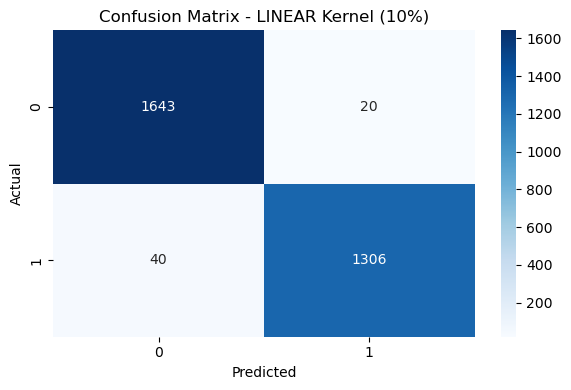


 Training SVM with kernel: RBF
Fitting 5 folds for each of 25 candidates, totalling 125 fits

 Best parameters for rbf: {'C': 100, 'gamma': 0.01}

 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1663
           1       0.98      0.98      0.98      1346

    accuracy                           0.98      3009
   macro avg       0.98      0.98      0.98      3009
weighted avg       0.98      0.98      0.98      3009

 Accuracy: 0.979063
️ Training Time: 2.5267 seconds


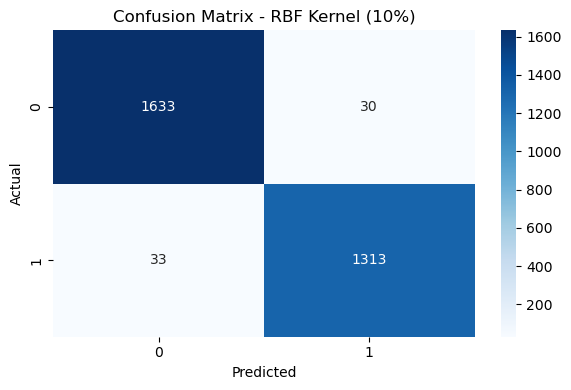


 Training SVM with kernel: POLY
Fitting 5 folds for each of 32 candidates, totalling 160 fits

 Best parameters for poly: {'C': 100, 'degree': 3, 'gamma': 'scale'}

 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1663
           1       0.99      0.95      0.97      1346

    accuracy                           0.98      3009
   macro avg       0.98      0.97      0.98      3009
weighted avg       0.98      0.98      0.98      3009

 Accuracy: 0.975407
️ Training Time: 2.4487 seconds


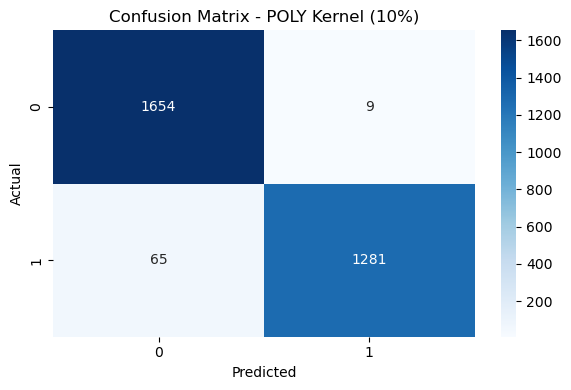


 Training SVM with kernel: SIGMOID
Fitting 5 folds for each of 8 candidates, totalling 40 fits

 Best parameters for sigmoid: {'C': 0.1, 'gamma': 'scale'}

 Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1663
           1       0.99      0.93      0.96      1346

    accuracy                           0.96      3009
   macro avg       0.97      0.96      0.96      3009
weighted avg       0.96      0.96      0.96      3009

 Accuracy: 0.963111
️ Training Time: 0.6617 seconds


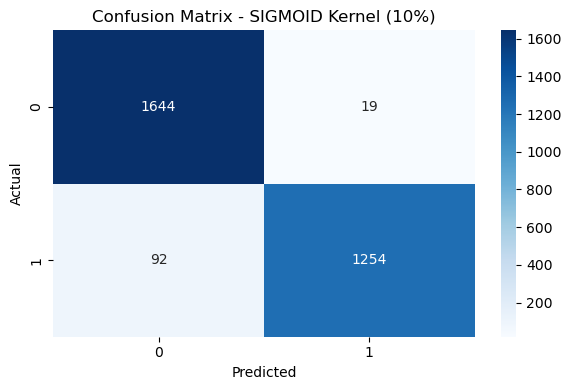

In [28]:
best_models_10 = train_and_evaluate_svm_with_portion(0.1, kernel_params)


 Training with 20.0% of the data (601 samples)

 Class distribution in training subset:
 - Class 0: 332 samples
 - Class 1: 269 samples

 Training SVM with kernel: LINEAR
Fitting 5 folds for each of 6 candidates, totalling 30 fits

 Best parameters for linear: {'C': 10}

 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1663
           1       0.99      0.97      0.98      1346

    accuracy                           0.98      3009
   macro avg       0.98      0.98      0.98      3009
weighted avg       0.98      0.98      0.98      3009

 Accuracy: 0.982054
️ Training Time: 11.8444 seconds


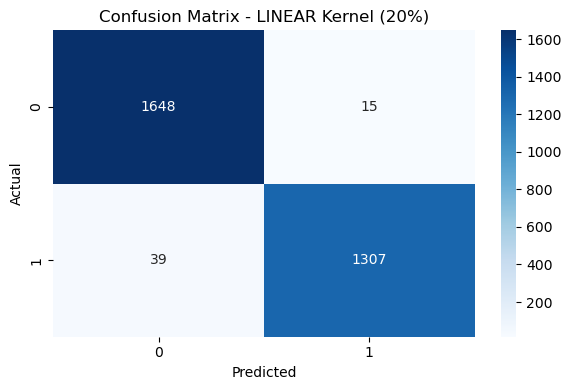


 Training SVM with kernel: RBF
Fitting 5 folds for each of 25 candidates, totalling 125 fits

 Best parameters for rbf: {'C': 10, 'gamma': 0.1}

 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1663
           1       0.99      0.98      0.98      1346

    accuracy                           0.98      3009
   macro avg       0.98      0.98      0.98      3009
weighted avg       0.98      0.98      0.98      3009

 Accuracy: 0.983716
️ Training Time: 4.0140 seconds


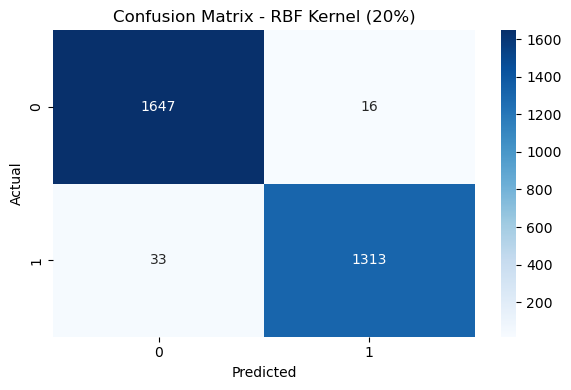


 Training SVM with kernel: POLY
Fitting 5 folds for each of 32 candidates, totalling 160 fits

 Best parameters for poly: {'C': 100, 'degree': 3, 'gamma': 'scale'}

 Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1663
           1       1.00      0.95      0.97      1346

    accuracy                           0.98      3009
   macro avg       0.98      0.98      0.98      3009
weighted avg       0.98      0.98      0.98      3009

 Accuracy: 0.977733
️ Training Time: 4.0773 seconds


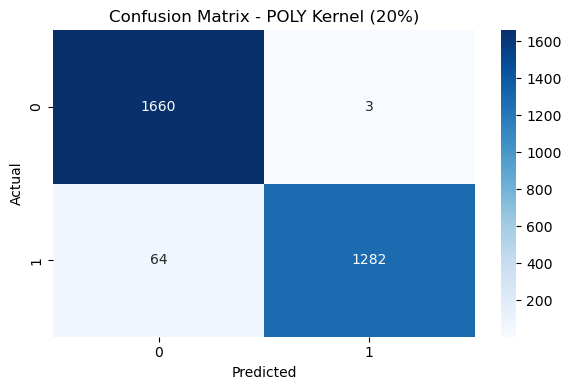


 Training SVM with kernel: SIGMOID
Fitting 5 folds for each of 8 candidates, totalling 40 fits

 Best parameters for sigmoid: {'C': 0.1, 'gamma': 'scale'}

 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      1663
           1       0.99      0.91      0.95      1346

    accuracy                           0.96      3009
   macro avg       0.96      0.95      0.96      3009
weighted avg       0.96      0.96      0.96      3009

 Accuracy: 0.957793
️ Training Time: 0.7742 seconds


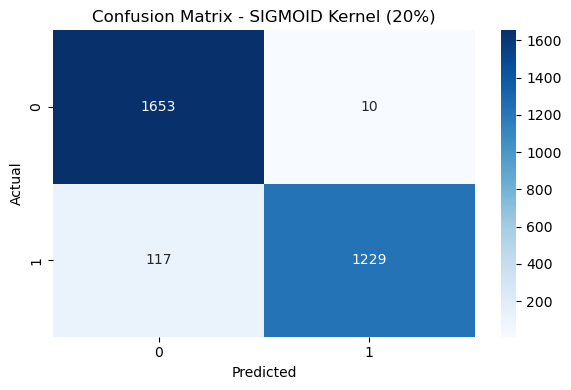

In [29]:
best_models_20 = train_and_evaluate_svm_with_portion(0.2, kernel_params)


 Training with 40.0% of the data (1203 samples)

 Class distribution in training subset:
 - Class 0: 665 samples
 - Class 1: 538 samples

 Training SVM with kernel: LINEAR
Fitting 5 folds for each of 6 candidates, totalling 30 fits

 Best parameters for linear: {'C': 10000}

 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1663
           1       0.99      0.97      0.98      1346

    accuracy                           0.98      3009
   macro avg       0.98      0.98      0.98      3009
weighted avg       0.98      0.98      0.98      3009

 Accuracy: 0.983383
️ Training Time: 31.3143 seconds


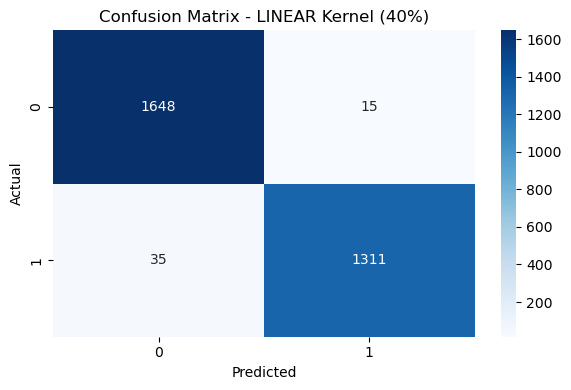


 Training SVM with kernel: RBF
Fitting 5 folds for each of 25 candidates, totalling 125 fits

 Best parameters for rbf: {'C': 100, 'gamma': 0.1}

 Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1663
           1       0.99      0.99      0.99      1346

    accuracy                           0.99      3009
   macro avg       0.99      0.99      0.99      3009
weighted avg       0.99      0.99      0.99      3009

 Accuracy: 0.990695
️ Training Time: 12.8898 seconds


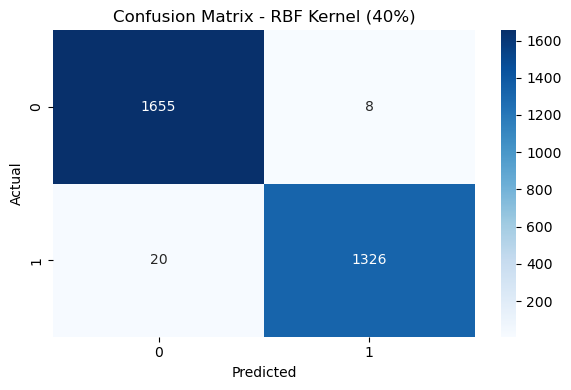


 Training SVM with kernel: POLY
Fitting 5 folds for each of 32 candidates, totalling 160 fits

 Best parameters for poly: {'C': 100, 'degree': 3, 'gamma': 'scale'}

 Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1663
           1       1.00      0.96      0.98      1346

    accuracy                           0.98      3009
   macro avg       0.98      0.98      0.98      3009
weighted avg       0.98      0.98      0.98      3009

 Accuracy: 0.980724
️ Training Time: 12.9539 seconds


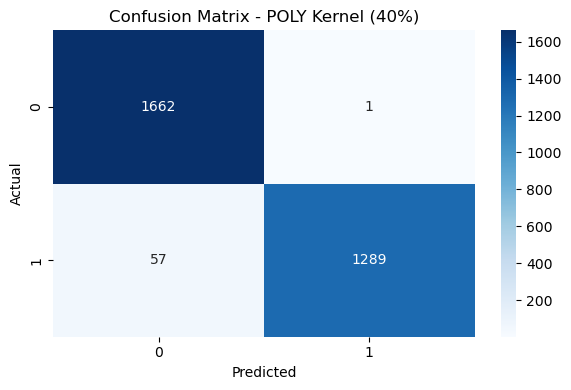


 Training SVM with kernel: SIGMOID
Fitting 5 folds for each of 8 candidates, totalling 40 fits

 Best parameters for sigmoid: {'C': 0.1, 'gamma': 'auto'}

 Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      1663
           1       0.99      0.92      0.95      1346

    accuracy                           0.96      3009
   macro avg       0.96      0.95      0.96      3009
weighted avg       0.96      0.96      0.96      3009

 Accuracy: 0.958458
️ Training Time: 2.8159 seconds


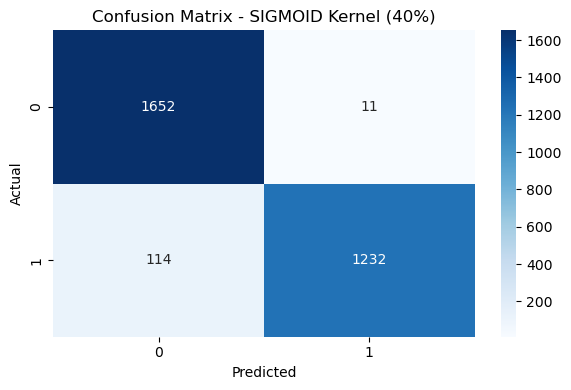

In [30]:
best_models_40 = train_and_evaluate_svm_with_portion(0.4, kernel_params)


 Training with 60.0% of the data (1805 samples)

 Class distribution in training subset:
 - Class 0: 998 samples
 - Class 1: 807 samples

 Training SVM with kernel: LINEAR
Fitting 5 folds for each of 6 candidates, totalling 30 fits

 Best parameters for linear: {'C': 100}

 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1663
           1       0.99      0.98      0.98      1346

    accuracy                           0.98      3009
   macro avg       0.98      0.98      0.98      3009
weighted avg       0.98      0.98      0.98      3009

 Accuracy: 0.983716
️ Training Time: 142.8722 seconds


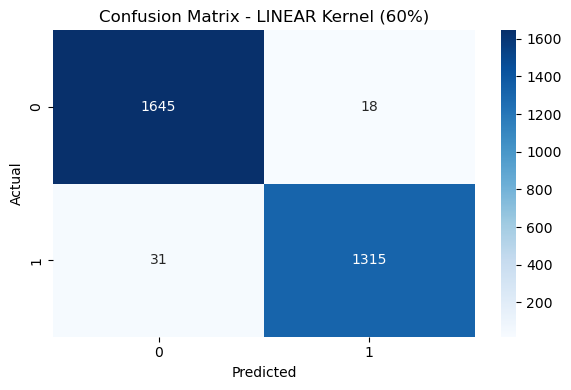


 Training SVM with kernel: RBF
Fitting 5 folds for each of 25 candidates, totalling 125 fits

 Best parameters for rbf: {'C': 100, 'gamma': 0.1}

 Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1663
           1       1.00      0.99      0.99      1346

    accuracy                           0.99      3009
   macro avg       0.99      0.99      0.99      3009
weighted avg       0.99      0.99      0.99      3009

 Accuracy: 0.994350
️ Training Time: 23.6649 seconds


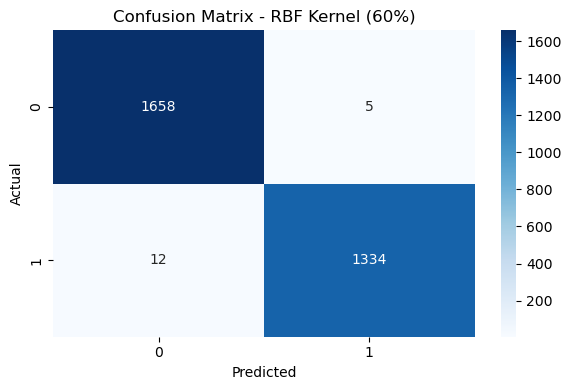


 Training SVM with kernel: POLY
Fitting 5 folds for each of 32 candidates, totalling 160 fits

 Best parameters for poly: {'C': 100, 'degree': 3, 'gamma': 'scale'}

 Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1663
           1       1.00      0.96      0.98      1346

    accuracy                           0.98      3009
   macro avg       0.98      0.98      0.98      3009
weighted avg       0.98      0.98      0.98      3009

 Accuracy: 0.982386
️ Training Time: 22.5081 seconds


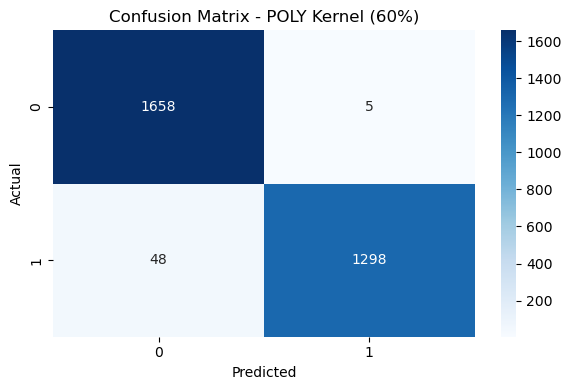


 Training SVM with kernel: SIGMOID
Fitting 5 folds for each of 8 candidates, totalling 40 fits

 Best parameters for sigmoid: {'C': 0.1, 'gamma': 'scale'}

 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      1663
           1       0.98      0.91      0.95      1346

    accuracy                           0.95      3009
   macro avg       0.96      0.95      0.95      3009
weighted avg       0.96      0.95      0.95      3009

 Accuracy: 0.954802
️ Training Time: 2.3213 seconds


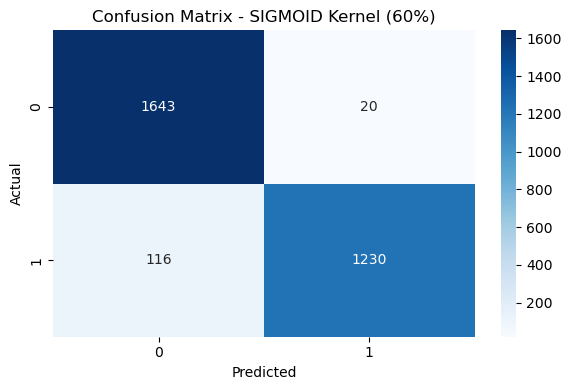

In [31]:
best_models_60 = train_and_evaluate_svm_with_portion(0.6, kernel_params)


 Training with 80.0% of the data (2407 samples)

 Class distribution in training subset:
 - Class 0: 1330 samples
 - Class 1: 1077 samples

 Training SVM with kernel: LINEAR
Fitting 5 folds for each of 6 candidates, totalling 30 fits

 Best parameters for linear: {'C': 1000}

 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1663
           1       0.99      0.98      0.98      1346

    accuracy                           0.99      3009
   macro avg       0.99      0.98      0.98      3009
weighted avg       0.99      0.99      0.99      3009

 Accuracy: 0.985045
️ Training Time: 152.6338 seconds


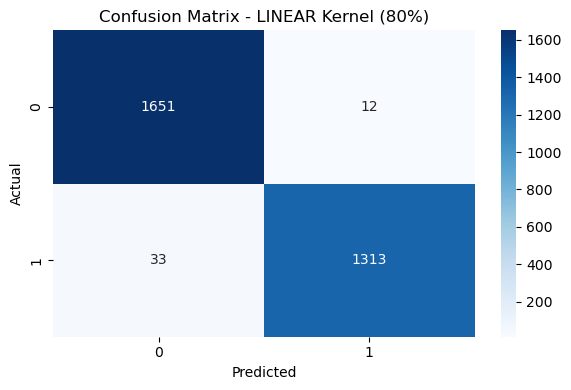


 Training SVM with kernel: RBF
Fitting 5 folds for each of 25 candidates, totalling 125 fits

 Best parameters for rbf: {'C': 100, 'gamma': 0.1}

 Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1663
           1       1.00      0.99      0.99      1346

    accuracy                           0.99      3009
   macro avg       0.99      0.99      0.99      3009
weighted avg       0.99      0.99      0.99      3009

 Accuracy: 0.994018
️ Training Time: 39.3512 seconds


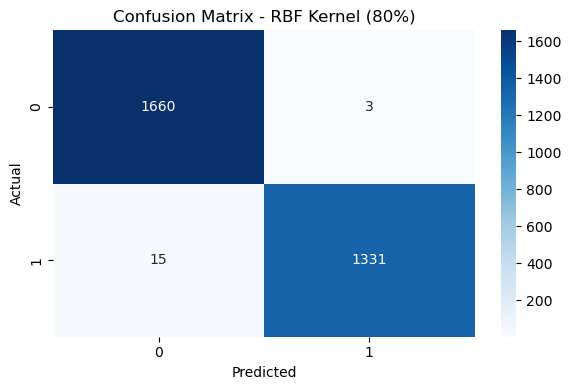


 Training SVM with kernel: POLY
Fitting 5 folds for each of 32 candidates, totalling 160 fits

 Best parameters for poly: {'C': 100, 'degree': 3, 'gamma': 'scale'}

 Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1663
           1       1.00      0.97      0.98      1346

    accuracy                           0.99      3009
   macro avg       0.99      0.98      0.99      3009
weighted avg       0.99      0.99      0.99      3009

 Accuracy: 0.985710
️ Training Time: 30.8299 seconds


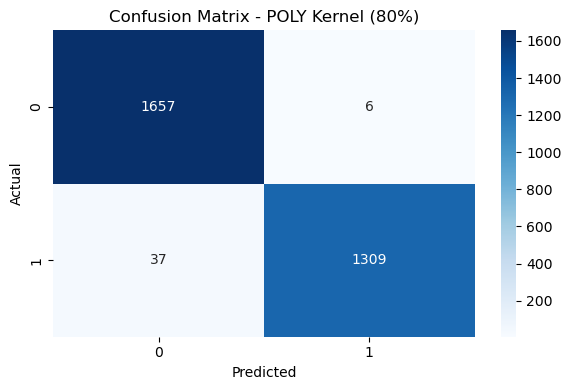


 Training SVM with kernel: SIGMOID
Fitting 5 folds for each of 8 candidates, totalling 40 fits

 Best parameters for sigmoid: {'C': 0.1, 'gamma': 'auto'}

 Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      1663
           1       0.99      0.92      0.95      1346

    accuracy                           0.96      3009
   macro avg       0.96      0.95      0.96      3009
weighted avg       0.96      0.96      0.96      3009

 Accuracy: 0.957129
️ Training Time: 2.8016 seconds


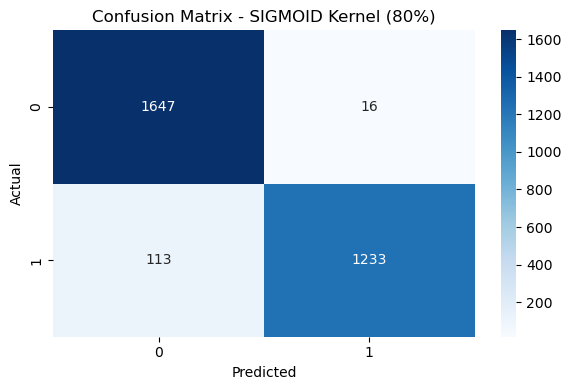

In [32]:
best_models_80 = train_and_evaluate_svm_with_portion(0.8, kernel_params)


 Training with 100.0% of the data (3009 samples)

 Class distribution in training subset:
 - Class 0: 1663 samples
 - Class 1: 1346 samples

 Training SVM with kernel: LINEAR
Fitting 5 folds for each of 6 candidates, totalling 30 fits

 Best parameters for linear: {'C': 10000}

 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1663
           1       0.99      0.97      0.98      1346

    accuracy                           0.98      3009
   macro avg       0.99      0.98      0.98      3009
weighted avg       0.98      0.98      0.98      3009

 Accuracy: 0.984713
️ Training Time: 240.9966 seconds


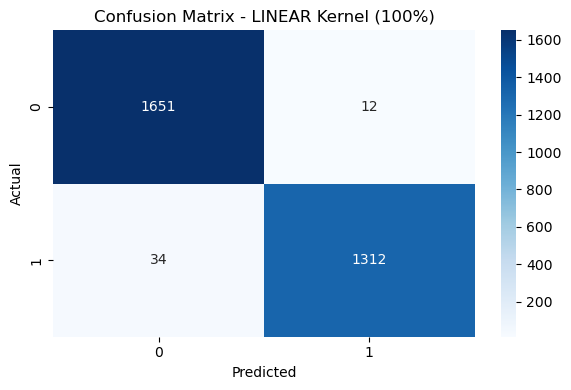


 Training SVM with kernel: RBF
Fitting 5 folds for each of 25 candidates, totalling 125 fits

 Best parameters for rbf: {'C': 100, 'gamma': 0.1}

 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1663
           1       1.00      0.99      1.00      1346

    accuracy                           1.00      3009
   macro avg       1.00      1.00      1.00      3009
weighted avg       1.00      1.00      1.00      3009

 Accuracy: 0.997009
️ Training Time: 66.1414 seconds


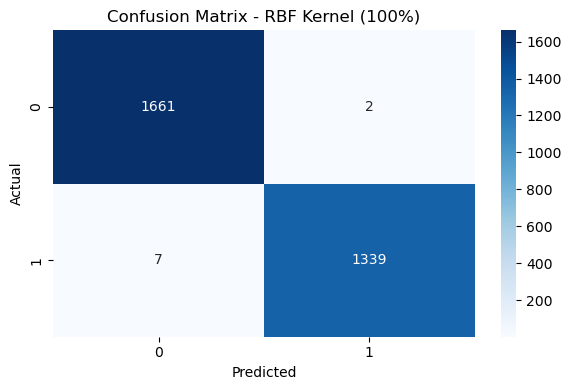


 Training SVM with kernel: POLY
Fitting 5 folds for each of 32 candidates, totalling 160 fits

 Best parameters for poly: {'C': 100, 'degree': 3, 'gamma': 'scale'}

 Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1663
           1       1.00      0.98      0.99      1346

    accuracy                           0.99      3009
   macro avg       0.99      0.99      0.99      3009
weighted avg       0.99      0.99      0.99      3009

 Accuracy: 0.988036
️ Training Time: 58.0194 seconds


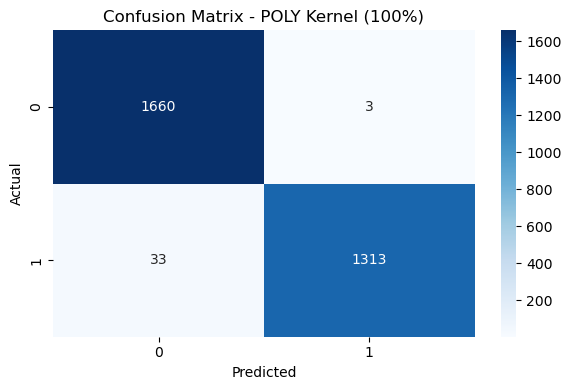


 Training SVM with kernel: SIGMOID
Fitting 5 folds for each of 8 candidates, totalling 40 fits

 Best parameters for sigmoid: {'C': 0.1, 'gamma': 'auto'}

 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      1663
           1       0.98      0.91      0.95      1346

    accuracy                           0.95      3009
   macro avg       0.96      0.95      0.95      3009
weighted avg       0.96      0.95      0.95      3009

 Accuracy: 0.954470
️ Training Time: 4.4875 seconds


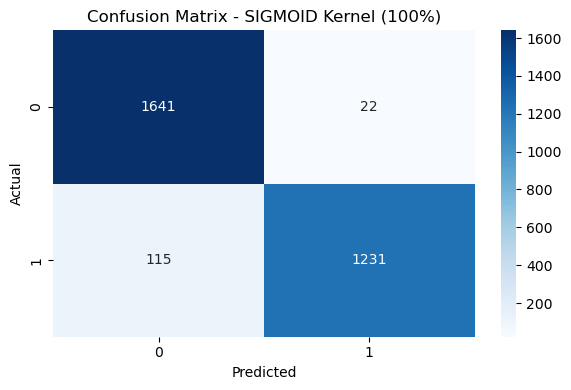

In [46]:
best_models_100 = train_and_evaluate_svm_with_portion(1.0, kernel_params)